# Step 1: Importing Data Set

In [32]:
import pandas as pd

In [33]:
df= pd.read_csv('diabetes.csv')
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


# Step 2: Understanding Data Set

In [34]:
df.shape

(768, 9)

In [35]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [36]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


# Step 3: EDA

### Finding Missing Values

In [37]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [38]:
(df == 0).sum()

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

### Finding Dupliacte Rows

In [39]:
df.duplicated().sum()

np.int64(0)

# Checking Traget Column

In [40]:
df["Outcome"].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

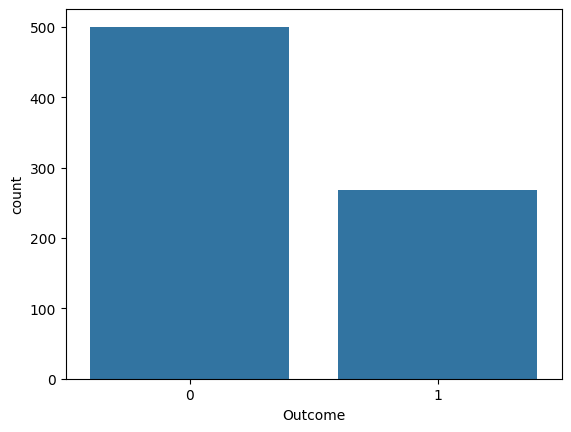

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Outcome", data=df)
plt.show()

### Correlation Analysis

In [42]:
corr_matrix = df.corr()

corr_matrix["Outcome"].sort_values(
    ascending=False
)

Outcome                     1.000000
Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068
Name: Outcome, dtype: float64

### Outlier Detection

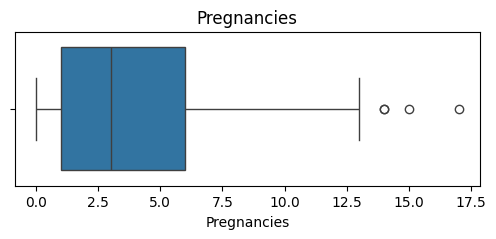

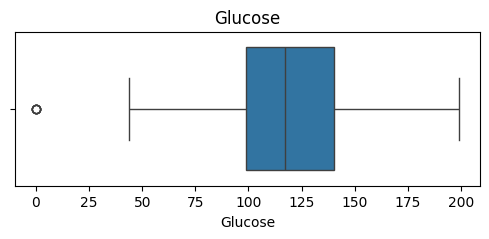

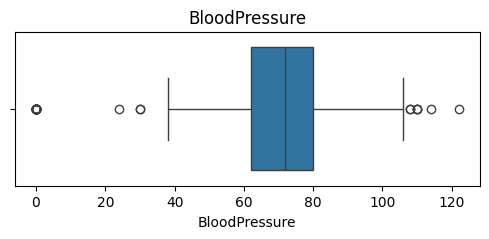

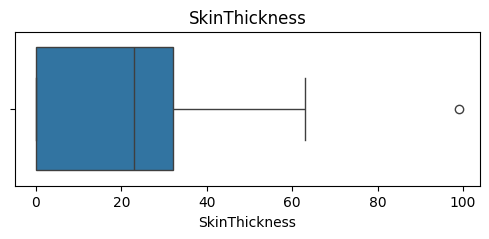

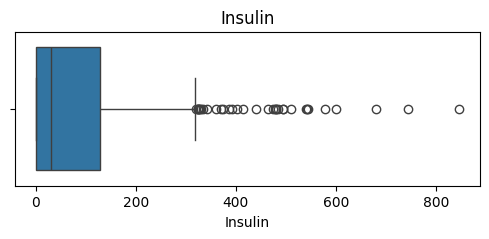

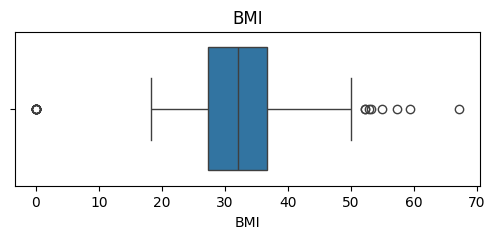

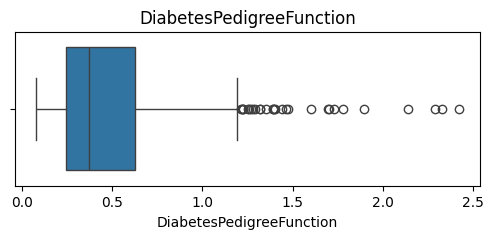

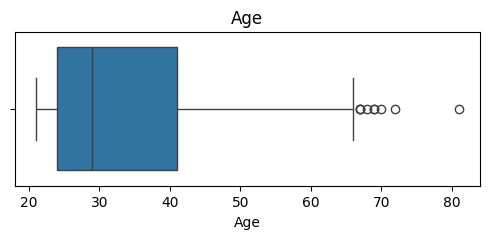

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age"
]

for col in num_cols:
    
    plt.figure(figsize=(6,2))
    
    sns.boxplot(x=df[col])
    
    plt.title(col)
    
    plt.show()

###  Distribution Analysis

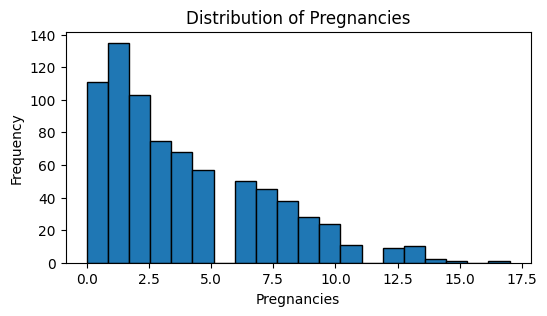

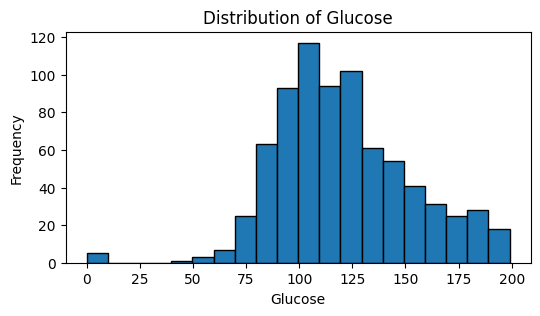

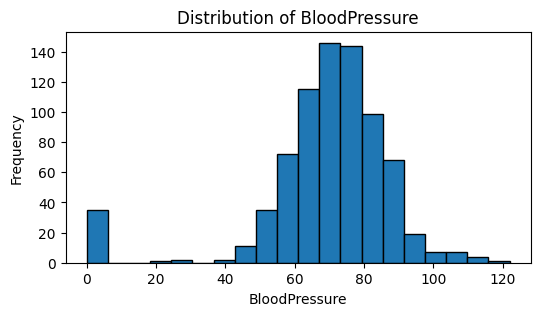

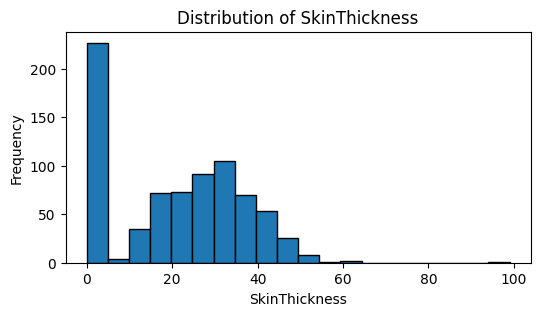

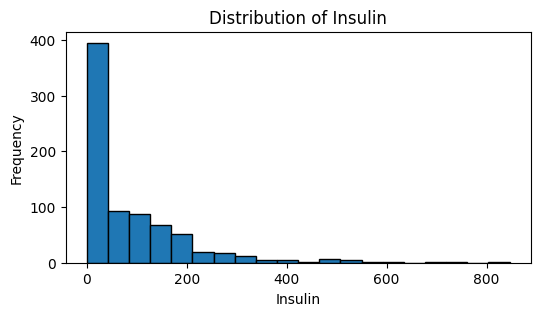

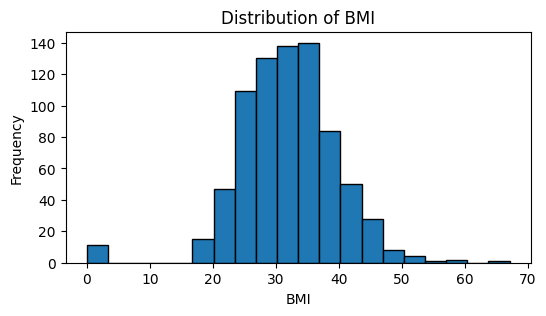

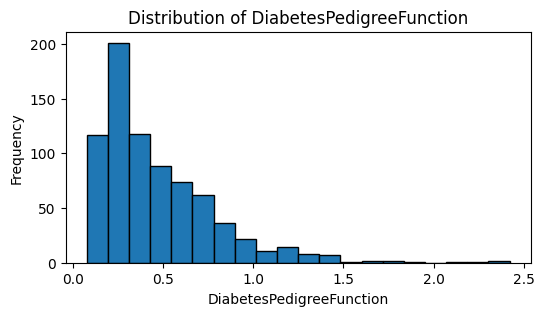

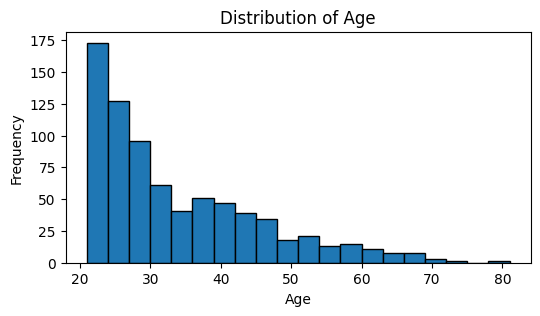

In [44]:
import matplotlib.pyplot as plt

num_cols = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age"
]

for col in num_cols:
    plt.figure(figsize=(6,3))
    plt.hist(df[col], bins=20, edgecolor='black')
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

### Skewness Analysis

In [45]:
num_cols = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age"
]

df[num_cols].skew().sort_values(ascending=False)

Insulin                     2.272251
DiabetesPedigreeFunction    1.919911
Age                         1.129597
Pregnancies                 0.901674
Glucose                     0.173754
SkinThickness               0.109372
BMI                        -0.428982
BloodPressure              -1.843608
dtype: float64

# Step 4: Train Test Split

In [46]:
# Features
X = df.drop("Outcome", axis=1)

# Target
Y = df["Outcome"]


from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)


print("X_train Shape:", X_train.shape)
print("X_test Shape :", X_test.shape)

print("Y_train Shape:", Y_train.shape)
print("Y_test Shape :", Y_test.shape)

X_train Shape: (614, 8)
X_test Shape : (154, 8)
Y_train Shape: (614,)
Y_test Shape : (154,)


# Step 5: Handling Missing Values

### Replace 0 to Nan

In [47]:
import numpy as np

cols_with_missing = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

X_train[cols_with_missing] = X_train[cols_with_missing].replace(0, np.nan)
X_test[cols_with_missing] = X_test[cols_with_missing].replace(0, np.nan)

### Check Missing Values Count

In [48]:
X_train.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                24
SkinThickness               176
Insulin                     290
BMI                           7
DiabetesPedigreeFunction      0
Age                           0
dtype: int64

### Check Missing Value Percentage

In [49]:
missing_percent = pd.DataFrame({
    "Missing %": X_train.isnull().mean() * 100
})

missing_percent.sort_values("Missing %", ascending=False)

,Missing %
Insulin,47.231270
SkinThickness,28.664495
BloodPressure,3.908795
BMI,1.140065
Glucose,0.814332
Pregnancies,0.000000
DiabetesPedigreeFunction,0.000000
Age,0.000000


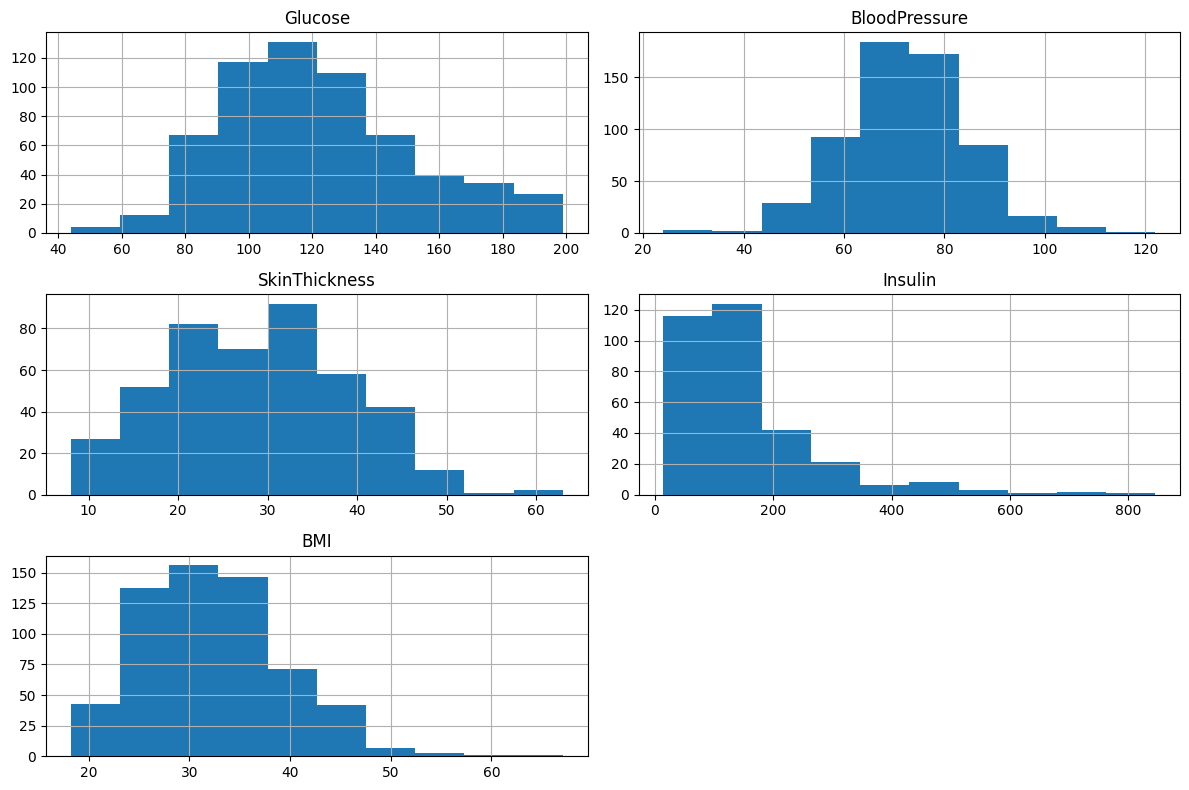

In [50]:
X_train[cols_with_missing].hist(figsize=(12,8))
plt.tight_layout()
plt.show()

### Median Imputation

In [51]:
from sklearn.impute import SimpleImputer

median_cols = ["Glucose", "BloodPressure", "BMI"]

median_imputer = SimpleImputer(strategy="median")

X_train[median_cols] = median_imputer.fit_transform(X_train[median_cols])
X_test[median_cols] = median_imputer.transform(X_test[median_cols])

### KNN Imputation

In [52]:
from sklearn.impute import KNNImputer

knn_cols = ["SkinThickness", "Insulin"]

knn_imputer = KNNImputer(n_neighbors=5)

X_train[knn_cols] = knn_imputer.fit_transform(X_train[knn_cols])
X_test[knn_cols] = knn_imputer.transform(X_test[knn_cols])

### Verifying Missing Values Are Gone?

In [53]:
X_train.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64

In [54]:
X_test.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64

# Step 6: Outlier Handling

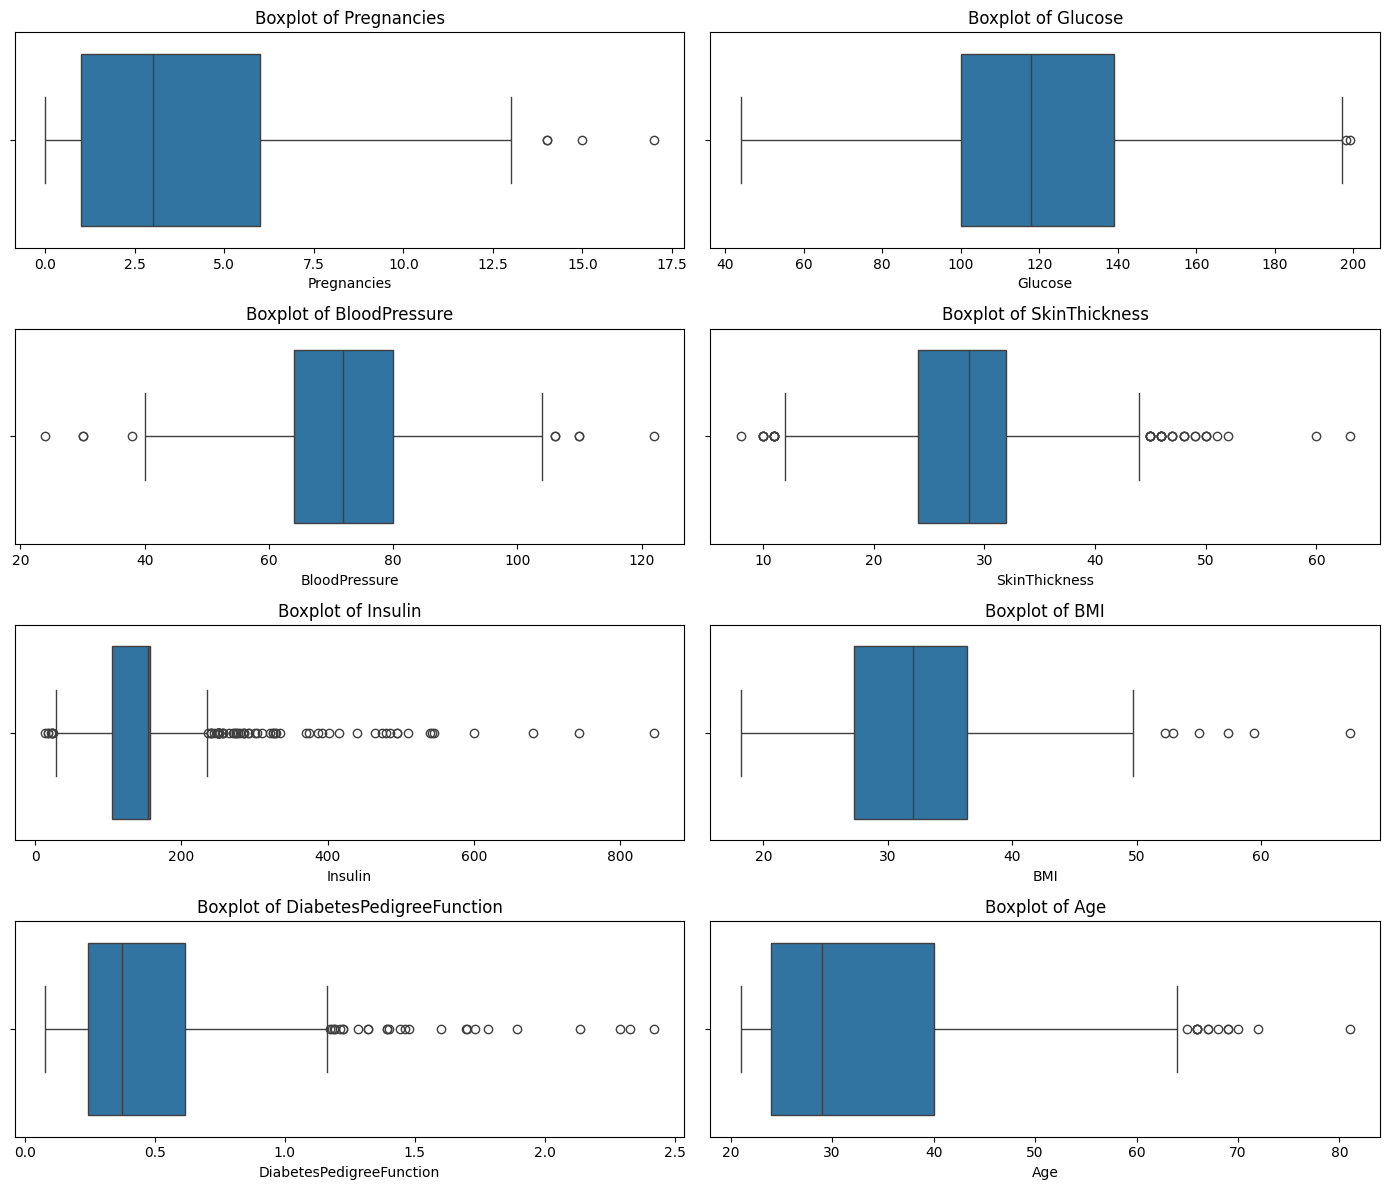

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

# Numerical columns
cols = X_train.columns

# Create subplots
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 12))
axes = axes.flatten()

# Generate boxplots
for i, col in enumerate(cols):
    sns.boxplot(x=X_train[col], ax=axes[i])
    axes[i].set_title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

# Step 7: Transformation

In [56]:
X_train.skew().sort_values(ascending=False)

Insulin                     2.946946
DiabetesPedigreeFunction    2.094005
Age                         1.181449
Pregnancies                 0.935022
BMI                         0.665417
Glucose                     0.570541
SkinThickness               0.283954
BloodPressure               0.006772
dtype: float64

In [59]:
from sklearn.preprocessing import PowerTransformer

# Features to transform
transform_cols = [
    'Insulin',
    'DiabetesPedigreeFunction',
    'Age',
    'Pregnancies',
    'BMI',
    'Glucose'
]

# Create transformer
pt = PowerTransformer(method='yeo-johnson')

# Fit on train, transform both train and test
X_train[transform_cols] = pt.fit_transform(X_train[transform_cols])
X_test[transform_cols] = pt.transform(X_test[transform_cols])

In [60]:
X_train[transform_cols].skew().sort_values(ascending=False)

Age                         0.152920
DiabetesPedigreeFunction    0.137778
Insulin                     0.056272
BMI                         0.000288
Glucose                    -0.000258
Pregnancies                -0.041350
dtype: float64

# Step 8: Scaling

In [61]:
from sklearn.preprocessing import StandardScaler

# Create scaler
scaler = StandardScaler()

# Scale train and test data
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Step 9: Model 

## Logistic Regression

In [62]:
from sklearn.linear_model import LogisticRegression

# Create Model
lr = LogisticRegression(random_state=42)

# Train Model
lr.fit(X_train, Y_train)

# Predictions
y_pred_lr = lr.predict(X_test)

### Evaluation Metrics for Logistic Regression

In [64]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# Classification Metrics
lr_accuracy = accuracy_score(Y_test, y_pred_lr)
lr_precision = precision_score(Y_test, y_pred_lr)
lr_recall = recall_score(Y_test, y_pred_lr)
lr_f1 = f1_score(Y_test, y_pred_lr)

# ROC-AUC
y_prob_lr = lr.predict_proba(X_test)[:,1]
lr_auc = roc_auc_score(Y_test, y_prob_lr)

# Print Results
print("Accuracy :", lr_accuracy)
print("Precision :", lr_precision)
print("Recall :", lr_recall)
print("F1 Score :", lr_f1)
print("ROC-AUC :", lr_auc)

Accuracy : 0.7532467532467533
Precision : 0.6545454545454545
Recall : 0.6545454545454545
F1 Score : 0.6545454545454545
ROC-AUC : 0.8205693296602388


## Gaussian Naive Bayes

In [65]:
from sklearn.naive_bayes import GaussianNB

# Create Model
gnb = GaussianNB()

# Train Model
gnb.fit(X_train, Y_train)

# Predictions
y_pred_gnb = gnb.predict(X_test)

### Evaluation Metrics for Naive Bayes

In [66]:
gnb_accuracy = accuracy_score(Y_test, y_pred_gnb)
gnb_precision = precision_score(Y_test, y_pred_gnb)
gnb_recall = recall_score(Y_test, y_pred_gnb)
gnb_f1 = f1_score(Y_test, y_pred_gnb)

y_prob_gnb = gnb.predict_proba(X_test)[:,1]
gnb_auc = roc_auc_score(Y_test, y_prob_gnb)

print("Accuracy :", gnb_accuracy)
print("Precision :", gnb_precision)
print("Recall :", gnb_recall)
print("F1 Score :", gnb_f1)
print("ROC-AUC :", gnb_auc)

Accuracy : 0.7467532467532467
Precision : 0.625
Recall : 0.7272727272727273
F1 Score : 0.6722689075630253
ROC-AUC : 0.8185491276400367


## KNN

In [67]:
from sklearn.neighbors import KNeighborsClassifier

# Create Model
knn = KNeighborsClassifier(n_neighbors=5)

# Train Model
knn.fit(X_train, Y_train)

# Predictions
y_pred_knn = knn.predict(X_test)

### Evauation Metrics for KNN

In [68]:
knn_accuracy = accuracy_score(Y_test, y_pred_knn)
knn_precision = precision_score(Y_test, y_pred_knn)
knn_recall = recall_score(Y_test, y_pred_knn)
knn_f1 = f1_score(Y_test, y_pred_knn)

y_prob_knn = knn.predict_proba(X_test)[:,1]
knn_auc = roc_auc_score(Y_test, y_prob_knn)

print("Accuracy :", knn_accuracy)
print("Precision :", knn_precision)
print("Recall :", knn_recall)
print("F1 Score :", knn_f1)
print("ROC-AUC :", knn_auc)

Accuracy : 0.7402597402597403
Precision : 0.6190476190476191
Recall : 0.7090909090909091
F1 Score : 0.6610169491525424
ROC-AUC : 0.782277318640955


## SVM

In [69]:
from sklearn.svm import SVC

# Create Model
svm = SVC(kernel='rbf', probability=True, random_state=42)

# Train Model
svm.fit(X_train, Y_train)

# Predictions
y_pred_svm = svm.predict(X_test)

C:\Users\Digital\AppData\Roaming\Python\Python313\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


### Evaluation Metrics for SVM

In [70]:
svm_accuracy = accuracy_score(Y_test, y_pred_svm)
svm_precision = precision_score(Y_test, y_pred_svm)
svm_recall = recall_score(Y_test, y_pred_svm)
svm_f1 = f1_score(Y_test, y_pred_svm)

y_prob_svm = svm.predict_proba(X_test)[:,1]
svm_auc = roc_auc_score(Y_test, y_prob_svm)

print("Accuracy :", svm_accuracy)
print("Precision :", svm_precision)
print("Recall :", svm_recall)
print("F1 Score :", svm_f1)
print("ROC-AUC :", svm_auc)

Accuracy : 0.7272727272727273
Precision : 0.6140350877192983
Recall : 0.6363636363636364
F1 Score : 0.625
ROC-AUC : 0.8119375573921028


## Decision Tree

In [71]:
from sklearn.tree import DecisionTreeClassifier

# Create Model
dt = DecisionTreeClassifier(random_state=42)

# Train Model
dt.fit(X_train, Y_train)

# Predictions
y_pred_dt = dt.predict(X_test)

### Evaluation Metrics for Decision Tree

In [72]:
dt_accuracy = accuracy_score(Y_test, y_pred_dt)
dt_precision = precision_score(Y_test, y_pred_dt)
dt_recall = recall_score(Y_test, y_pred_dt)
dt_f1 = f1_score(Y_test, y_pred_dt)

y_prob_dt = dt.predict_proba(X_test)[:,1]
dt_auc = roc_auc_score(Y_test, y_prob_dt)

print("Accuracy :", dt_accuracy)
print("Precision :", dt_precision)
print("Recall :", dt_recall)
print("F1 Score :", dt_f1)
print("ROC-AUC :", dt_auc)

Accuracy : 0.6688311688311688
Precision : 0.5333333333333333
Recall : 0.5818181818181818
F1 Score : 0.5565217391304348
ROC-AUC : 0.6494949494949495


# Step 10: Comparison Table

In [73]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "KNN",
        "SVM",
        "Decision Tree"
    ],
    "Accuracy": [
        lr_accuracy,
        gnb_accuracy,
        knn_accuracy,
        svm_accuracy,
        dt_accuracy
    ],
    "Precision": [
        lr_precision,
        gnb_precision,
        knn_precision,
        svm_precision,
        dt_precision
    ],
    "Recall": [
        lr_recall,
        gnb_recall,
        knn_recall,
        svm_recall,
        dt_recall
    ],
    "F1 Score": [
        lr_f1,
        gnb_f1,
        knn_f1,
        svm_f1,
        dt_f1
    ],
    "ROC-AUC": [
        lr_auc,
        gnb_auc,
        knn_auc,
        svm_auc,
        dt_auc
    ]
})

results.sort_values("ROC-AUC", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.753247,0.654545,0.654545,0.654545,0.820569
1,Naive Bayes,0.746753,0.625000,0.727273,0.672269,0.818549
3,SVM,0.727273,0.614035,0.636364,0.625000,0.811938
2,KNN,0.740260,0.619048,0.709091,0.661017,0.782277
4,Decision Tree,0.668831,0.533333,0.581818,0.556522,0.649495
